In [2]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

# Part 1. Bisection Method (10 pts.)

### 1. The first step in searching the root of a function is to graph the function and determine the interval  where the function is found to be zero. For this activity we will find the solution of the equation of the  bound states:

$$\sqrt{10-E_B}tan\sqrt{10-E_B}=\sqrt{E_B}$$

by finding the root of the equation

$$f(E) =\sqrt{10-E_B}tan\sqrt{10-E_B}-\sqrt{E_B}$$

Plot first the graph 𝑓(𝐸) vs. 𝐸 then estimate the interval where the function is found to be zero

   E       func
0  0   0.065421
1  1  -1.427640
2  2  -2.330119
3  3  -3.163177
4  4  -4.030327
5  5  -5.086063
6  6  -6.819569
7  7 -13.293591
8  8   6.129370
9  9  -1.442592


<ipython-input-33-1ef3ec904b27>:2: RuntimeWarning: invalid value encountered in sqrt
  return np.sqrt(10-E_B)*np.tan(np.sqrt(10-E_B)) - np.sqrt(E_B)
<ipython-input-33-1ef3ec904b27>:2: RuntimeWarning: invalid value encountered in sqrt
  return np.sqrt(10-E_B)*np.tan(np.sqrt(10-E_B)) - np.sqrt(E_B)


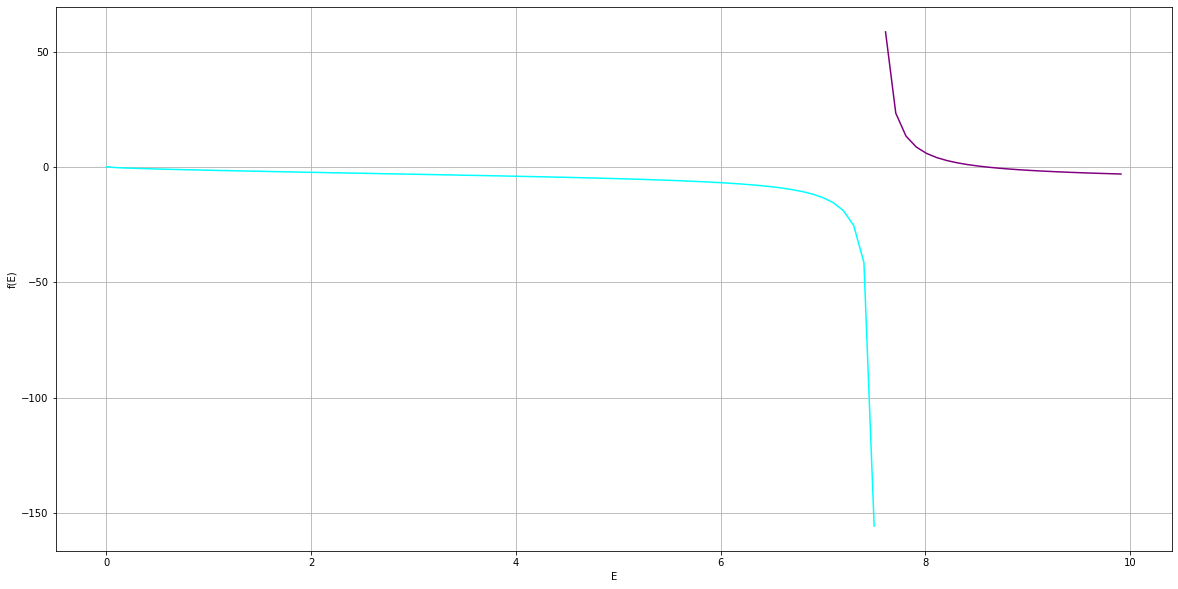

In [33]:
def f1(E_B):
    return np.sqrt(10-E_B)*np.tan(np.sqrt(10-E_B)) - np.sqrt(E_B)
    
f1_vec = np.vectorize(f1)
f1_vec(np.arange(0,50,1))
E1 = np.arange(0,7,1)
E2 = np.arange(9,13,1)

df = pd.DataFrame(np.arange(0,10,1))
df = df.assign(func = pd.Series(f1_vec(np.arange(0,10,1))).values)
df = df.rename(columns={0:"E", 1:"f(x)"})
print(df)

fig, (ax1) = plt.subplots(1,figsize=(20,10))

ax1.plot(np.arange(0,7.6,0.1), f1_vec(np.arange(0,7.6,0.1)), color='cyan')
ax1.plot(np.arange(7.6112,12,0.1), f1_vec(np.arange(7.6112,12,0.1)), color='purple')
ax1.set_xlabel('E')
ax1.set_ylabel('f(E)')
ax1.grid(visible=True, which='major', axis='both')

# function can be estimated to be 0 betwen 7 and 8 or between 0 and 2

     N   x_[0,2]  x_pos_[0,2]  x_min_[0,2]    f(x)_[0,2]   x_[8,9]  \
0    0  1.000000     0.000000     1.000000 -1.427640e+00  8.500000   
1    1  0.500000     0.000000     0.500000 -8.903611e-01  8.750000   
2    2  0.250000     0.000000     0.250000 -5.596272e-01  8.625000   
3    3  0.125000     0.000000     0.125000 -3.508552e-01  8.562500   
4    4  0.062500     0.000000     0.062500 -2.159927e-01  8.593750   
5    5  0.031250     0.000000     0.031250 -1.270759e-01  8.578125   
6    6  0.015625     0.000000     0.015625 -6.744247e-02  8.585938   
7    7  0.007812     0.000000     0.007812 -2.689990e-02  8.589844   
8    8  0.003906     0.003906     0.007812  9.545409e-04  8.591797   
9    9  0.005859     0.003906     0.005859 -1.407512e-02  8.592773   
10  10  0.004883     0.003906     0.004883 -6.914148e-03  8.593262   
11  11  0.004395     0.003906     0.004395 -3.082505e-03  8.593018   
12  12  0.004150     0.003906     0.004150 -1.091878e-03  8.592896   
13  13  0.004028    

Text(0.5, 1.0, 'f(x) range 8-9')

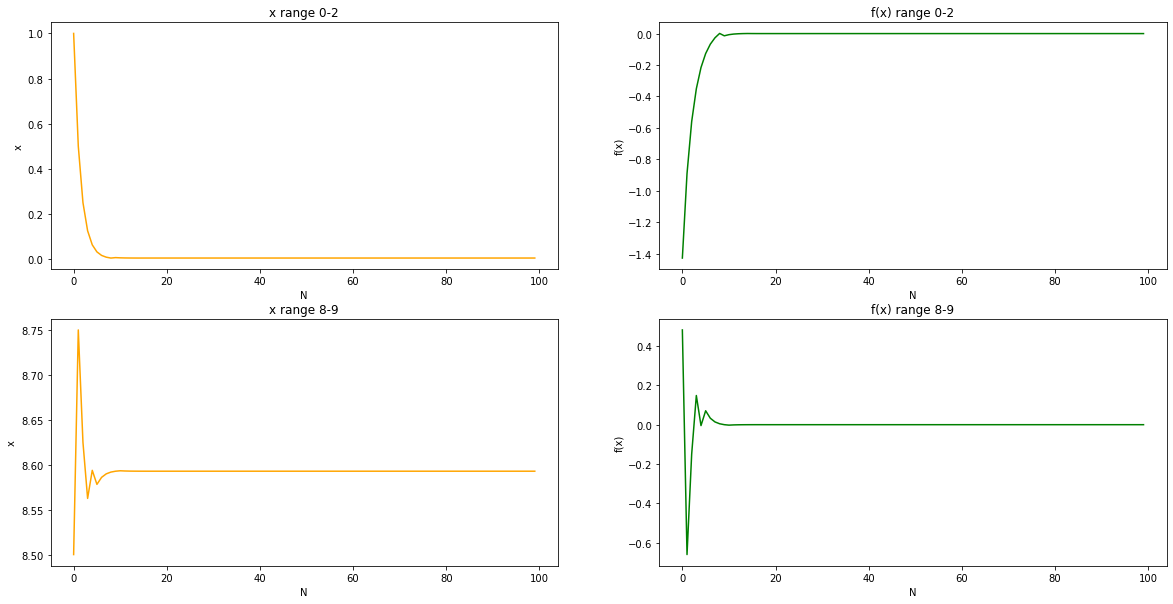

In [35]:
error = 1
x_plus = 0
x_minus = 2

def bisect(x_plus,x_minus):
    x_p, x_m, x_arr, i_arr,f_arr = [], [], [], [], []
    for i in range(100):
        x = (x_plus + x_minus)/2
        if f1(x)*f1(x_plus) > 0:
            x_plus = x
        else:
            x_minus = x
        x_arr.append(x)
        i_arr.append(i)
        x_p.append(x_plus)
        x_m.append(x_minus)
        f_arr.append(f1(x))
        i += 1
    return i_arr, x_arr, x_p, x_m, f_arr



bis_arr = bisect(x_plus,x_minus)
bis_arr_1 = bisect(8,9)
fig, ((ax1, ax2), (ax3, ax4)) = plt.subplots(2,2,figsize=(20,10))

pd.set_option("display.max_rows", None, "display.max_columns", None)
j = {'N':bis_arr[0],'x_[0,2]': bis_arr[1],'x_pos_[0,2]': bis_arr[2], 'x_min_[0,2]': bis_arr[3],'f(x)_[0,2]':bis_arr[4],
     'x_[8,9]': bis_arr_1[1],'x_pos_[8,9]': bis_arr_1[2], 'x_min_[8,9]': bis_arr_1[3],'f(x)_[8,9]':bis_arr_1[4]}
df = pd.DataFrame(j)
print(df)

ax1.plot(bis_arr[0],bis_arr[1], color='orange')
ax1.set_xlabel("N")
ax1.set_ylabel("x")
ax1.set_title('x range 0-2')

ax2.plot(bis_arr[0],bis_arr[4], color = 'green')
ax2.set_xlabel("N")
ax2.set_ylabel("f(x)")
ax2.set_title('f(x) range 0-2')

ax3.plot(bis_arr_1[0],bis_arr_1[1], color='orange')
ax3.set_xlabel("N")
ax3.set_ylabel("x")
ax3.set_title('x range 8-9')

ax4.plot(bis_arr_1[0],bis_arr_1[4], color = 'green')
ax4.set_xlabel("N")
ax4.set_ylabel("f(x)")
ax4.set_title('f(x) range 8-9')

#### first root  x = 8.592785 , f(x) = -3.552714e-15 at N = 47
#### second root  x = 0.004019 , f(x) = 1.387779e-17 at N = 59

### 2. Write a program in Python to find the root of 𝑓(𝐸) using the Bisection method. Warning: The tangent  function has singularities, and your algorithm may not function accurately near these singularities. One  remedy is to use different but equivalent form of Eqn. (1) which is:

$$\sqrt{E_B} cot\sqrt{10-E_B}-\sqrt{10-E_B}=0$$

     N   x_[0,2]  x_pos_[0,2]  x_min_[0,2]    f(x)_[0,2]
0    0  8.000000     8.000000     9.000000 -9.676752e-01
1    1  8.500000     8.500000     9.000000 -1.735402e-01
2    2  8.750000     8.500000     8.750000  3.209534e-01
3    3  8.625000     8.500000     8.625000  6.281716e-02
4    4  8.562500     8.562500     8.625000 -5.780907e-02
5    5  8.593750     8.562500     8.593750  1.860987e-03
6    6  8.578125     8.578125     8.593750 -2.813073e-02
7    7  8.585938     8.585938     8.593750 -1.317454e-02
8    8  8.589844     8.589844     8.593750 -5.666759e-03
9    9  8.591797     8.591797     8.593750 -1.905389e-03
10  10  8.592773     8.592773     8.593750 -2.282778e-05
11  11  8.593262     8.592773     8.593262  9.189228e-04
12  12  8.593018     8.592773     8.593018  4.480083e-04
13  13  8.592896     8.592773     8.592896  2.125805e-04
14  14  8.592834     8.592773     8.592834  9.487389e-05
15  15  8.592804     8.592773     8.592804  3.602244e-05
16  16  8.592789     8.592773  

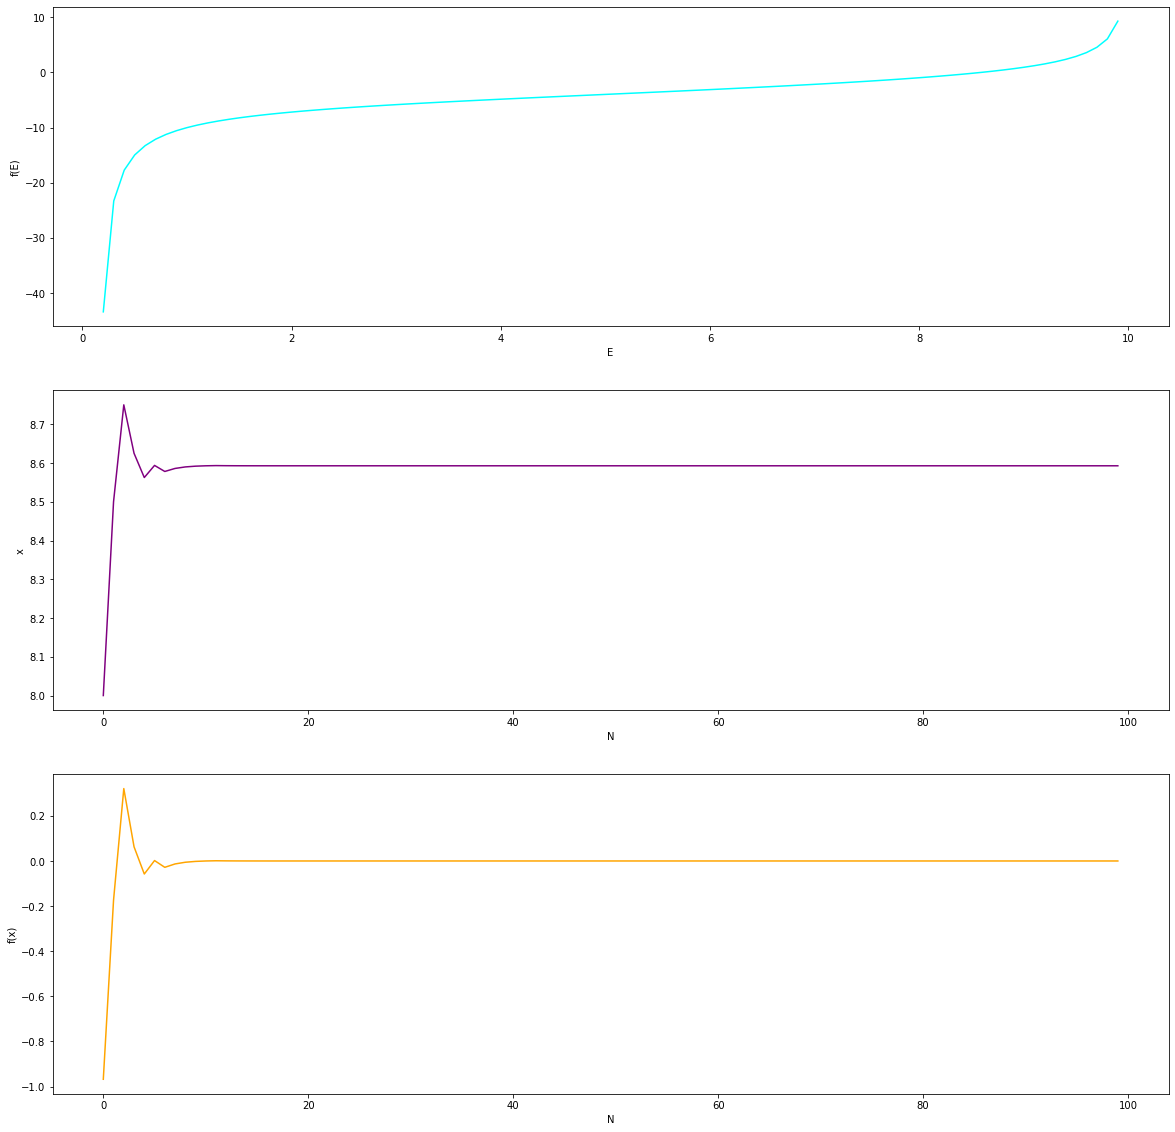

In [36]:
def f2(E_B):
    return np.sqrt(E_B)*((1/np.tan(np.sqrt(10-E_B)))) - np.sqrt(10-E_B)

f2_vec = np.vectorize(f2)

def bisect2(x_plus,x_minus):
    x_p, x_m, x_arr, i_arr,f_arr = [], [], [], [], []
    for i in range(100):
        x = (x_plus + x_minus)/2
        if f2(x)*f2(x_plus) > 0:
            x_plus = x
        else:
            x_minus = x
        x_arr.append(x)
        i_arr.append(i)
        x_p.append(x_plus)
        x_m.append(x_minus)
        f_arr.append(f2(x))
        i += 1
    return i_arr, x_arr, x_p, x_m, f_arr


bis_arr2 = bisect2(7,9)
bis_arr2_2 = bisect2(0,10)

fig, (ax1, ax2, ax3) = plt.subplots(3,figsize=(20,20))

ax1.plot(np.arange(0.2,10,0.1),f2_vec(np.arange(0.2,10,0.1)),color='cyan')
ax1.set_xlabel("E")
ax1.set_ylabel("f(E)")

ax2.plot(bis_arr2[0],bis_arr2[1],color='purple')
ax2.set_xlabel("N")
ax2.set_ylabel("x")

ax3.plot(bis_arr2[0],bis_arr2[4],color='orange')
ax3.set_xlabel("N")
ax3.set_ylabel("f(x)")

j = {'N':bis_arr2[0],'x_[0,2]': bis_arr2[1],'x_pos_[0,2]': bis_arr2[2], 'x_min_[0,2]': bis_arr2[3],'f(x)_[0,2]':bis_arr2[4]
    }
df = pd.DataFrame(j)
print(df)

The first graph corresponds to 

$$\sqrt{E_B} cot\sqrt{10-E_B}-\sqrt{10-E_B}=0$$

wherein we see that the graph only intersects the x-axis (0) at a single point. We can also calrify this using a graphics calculator to see that from the graph of the function only exists from (0,10) where we have infinites as 0 and 10

at x = 8.592785, f(x) = 1.554312e-15

## 3. Find the value/values of the bound state’s energy 𝐸𝐵 which are the root/roots, the value of 𝑓(𝐸𝐵) which is also the error, and the number of iterations. 

1.$$f(E) =\sqrt{10-E_B}tan\sqrt{10-E_B}-\sqrt{E_B}$$

the roots for the equation above is $E_B$/x = 0.004019 and 8.592785

The value of f(EB) = 1.387779e-17 and 1.554312e-15 respectively

the number of iterations it took to reach the value is 47 and 59 respectively

2. $$\sqrt{E_B} cot\sqrt{10-E_B}-\sqrt{10-E_B}=0$$

the root for the equation above is $E_B$/x = 8.592785

The value of f(EB) = 1.554312e-15 

the number of iterations it took to reach the value is 48


# Part 2. Newton-Raphson Method (10 pts.)

1.) Create a program in Python that implements the Newton-Raphson method. Note that the algorithm for the Newton’s Raphson method is given by:

input x (First guess)
Initialize $\delta x$
Set error tolerance $\epsilon$
Repeat

$$f'(x)=\frac{f(x+\frac{\Delta x}{2})-f(x-\frac{\Delta x}{2})}{\Delta x}$$
$$\Delta x = - \frac{f(x)}{f'(x)}$$

new guess
$$x += \Delta x$$ 

check for convergence
$$Until |f(x)|\leq \epsilon$$

In [124]:
def NR1(x):
    
    def center1(h,x):
        return (f1(x + (h/2))-f1(x - (h/2)))/h

    x_arr, err, N = [],[],[]
    n = 0
    error = 1
    del_x = 0.0001
    while error > 10**-8:
        del_x = -(f1(x))/(center1(del_x, x))
        x += del_x
        error = f1(x)
        print(x, error)
        N.append(n)
        x_arr.append(x)
        err.append(error)
        n+=1
        if n == 100:
            break
        else:
            continue
        
    return N, x_arr, err

def NR2(x):
    
    def center2(h,x):
        return (f2(x + (h/2))-f2(x - (h/2)))/h
    
    x_arr, err, N = [],[],[]
    n = 0
    error = 1
    del_x = 0.0001
    while error > 10**-8:
        del_x = -(f2(x))/(center2(del_x, x))
        x += del_x
        error = f2(x)
        print(x, error)
        N.append(n)
        n+=1
        x_arr.append(x)
        err.append(error)
        if n == 100:
            break
        else:
            continue
            
    return N, x_arr, err
        

### 2. Apply the Newton-Raphson code to find the energy of the bound states 𝐸𝐵 from part 1. Note that  your initial guess must be closer to the answer from the Bisection method for the Newton–Raphson  algorithm to work.

In [142]:
wee = NR1(7.999)
pee = NR1(0.001)

j = {'N': wee[0],'x_value':wee[1],'f(x)': wee[2]}
k = {'N': pee[0],'x_value':pee[1],'f(x)': pee[2]}
df = pd.DataFrame(j)

dg = pd.DataFrame(k)

print("\n\nTable for root 8.592785\n\n",df,"\n\nTable for root 0.004019\n\n",dg)

8.26564045958553 2.201083672783385
8.488427471776347 0.5474297741960701
8.581958988223498 0.05208138879850699
8.592663339581936 0.0005811131156661098
8.59278525941109 7.537997692708132e-08
8.592785275229838 3.552713678800501e-15
0.003040149655242927 0.008752972846005277
0.0039419617017398935 0.0006515208922142773
0.004018790597041832 3.959030406383568e-06
0.004019262435244303 1.517340975087933e-10


Table for root 8.592785

    N   x_value          f(x)
0  0  8.265640  2.201084e+00
1  1  8.488427  5.474298e-01
2  2  8.581959  5.208139e-02
3  3  8.592663  5.811131e-04
4  4  8.592785  7.537998e-08
5  5  8.592785  3.552714e-15 

Table for root 0.004019

    N   x_value          f(x)
0  0  0.003040  8.752973e-03
1  1  0.003942  6.515209e-04
2  2  0.004019  3.959030e-06
3  3  0.004019  1.517341e-10


Text(0, 0.5, 'f(x)')

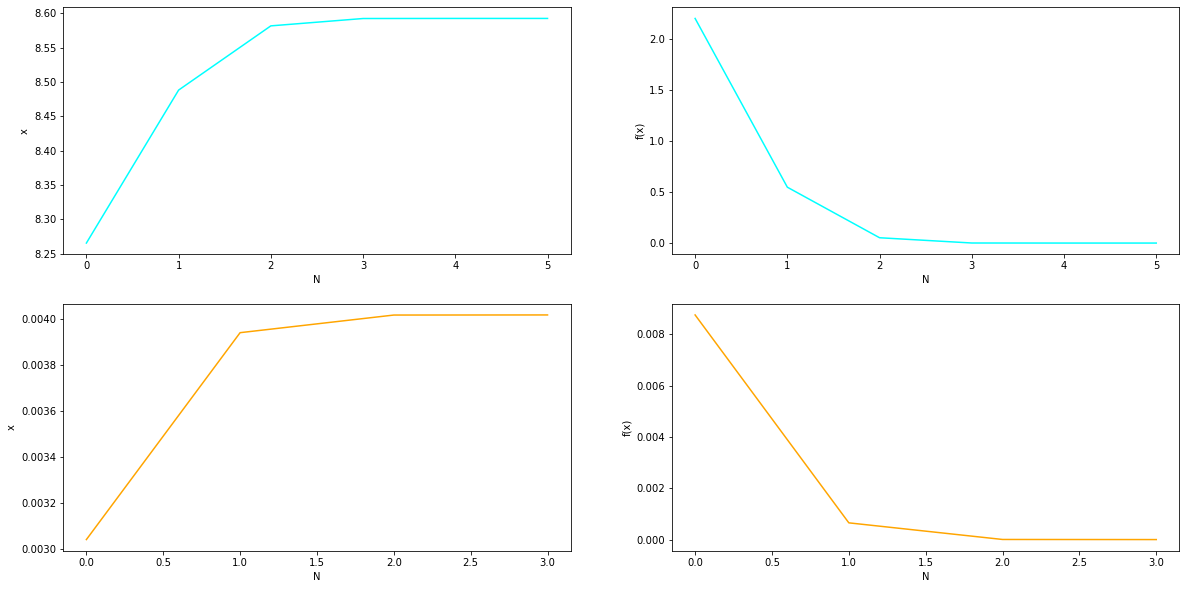

In [132]:
fig, ((ax1, ax2),(ax3, ax4)) = plt.subplots(2,2,figsize=(20,10))

"""Graphs for Newton-Raphson"""

#graphs for root 8.592785
ax1.plot(wee[0],wee[1], color='cyan')
ax1.set_xlabel("N")
ax1.set_ylabel("x")

ax2.plot(wee[0],wee[2], color='cyan')
ax2.set_xlabel("N")
ax2.set_ylabel("f(x)")

# graphs for root 0.004019
ax3.plot(pee[0],pee[1], color='orange')
ax3.set_xlabel("N")
ax3.set_ylabel("x")

ax4.plot(pee[0],pee[2], color='orange')
ax4.set_xlabel("N")
ax4.set_ylabel("f(x)")

### 3. Print the value of 𝑓(𝐸𝐵) which is also the error and the number of iterations.

#### 1.x = 8.592785,  f(x)= 3.552714e-15  

the number of iterations it took for it to reach that value is 5 iterations

#### 2. x = 0.004019,  f(x)= 1.517341e-10

the number of iterations it took for it to reach that value is 3 iterations

# Part 3 (10 pts.). 

### 1. Repeat part 1 and part 2 to solve the equation:

$$\sqrt{20-E_B}tan\sqrt{20-E_B}=\sqrt{E_B}$$

In [178]:
def f3(E_B):
    return np.sqrt(20-E_B)*np.tan(np.sqrt(20-E_B)) - np.sqrt(E_B)

def bisect3(x_plus,x_minus):
    x_p, x_m, x_arr, i_arr,f_arr = [], [], [], [], []
    for i in range(100):
        x = (x_plus + x_minus)/2
        if f3(x)*f3(x_plus) > 0:
            x_plus = x
        else:
            x_minus = x
        x_arr.append(x)
        i_arr.append(i)
        x_p.append(x_plus)
        x_m.append(x_minus)
        f_arr.append(f3(x))
        i += 1
    return i_arr, x_arr, x_p, x_m, f_arr


def NR3(x):
    
    def center3(h,x):
        return (f3(x + (h/2))-f3(x - (h/2)))/h
    
    x_arr, err, N = [],[],[]
    n = 0
    error = 1
    del_x = 0.0001
    while error > 10**-8:
        del_x = -(f3(x))/(center3(del_x, x))
        x += del_x
        error = f3(x)
        print(x, error)
        N.append(n)
        x_arr.append(x)
        err.append(error)
        n+=1
        if n == 100:
            break
        else:
            continue
        
    return N, x_arr, err, 

In [186]:
#table for bisection part 2

bis_arr3 = bisect3(1,8)
bis_arr4 = bisect3(18,20)

l = {'N':bis_arr3[0],'x_value_1': bis_arr3[1],'x_pos_1': bis_arr3[2], 'x_min_1': bis_arr3[3],'f(x)_1':bis_arr3[4],
                     'x_value_2': bis_arr4[1],'x_pos_2': bis_arr4[2], 'x_min_2': bis_arr4[3],'f(x)_2':bis_arr4[4]}
df = pd.DataFrame(l)
print(df)

     N  x_value_1   x_pos_1   x_min_1        f(x)_1  x_value_2    x_pos_2  \
0    0   4.500000  4.500000  8.000000  1.895327e+00  19.000000  18.000000   
1    1   6.250000  4.500000  6.250000 -1.414601e-01  18.500000  18.000000   
2    2   5.375000  5.375000  6.250000  7.910676e-01  18.250000  18.250000   
3    3   5.812500  5.812500  6.250000  3.068648e-01  18.375000  18.250000   
4    4   6.031250  6.031250  6.250000  7.857971e-02  18.312500  18.312500   
5    5   6.140625  6.031250  6.140625 -3.242955e-02  18.343750  18.343750   
6    6   6.085938  6.085938  6.140625  2.282274e-02  18.359375  18.359375   
7    7   6.113281  6.085938  6.113281 -4.865852e-03  18.367188  18.359375   
8    8   6.099609  6.099609  6.113281  8.962755e-03  18.363281  18.359375   
9    9   6.106445  6.106445  6.113281  2.044538e-03  18.361328  18.359375   
10  10   6.109863  6.106445  6.109863 -1.411634e-03  18.360352  18.360352   
11  11   6.108154  6.108154  6.109863  3.162078e-04  18.360840  18.360352   

#### 1. x = 6.108467 f(x) = -2.220446e-15 
 
the number of iterations it took for it to reach that value is 51

#### 2. x = 18.360520 f(x) = -1.776357e-14 

the number of iterations it took for it to reach that value is 49

Text(0, 0.5, 'f(x)')

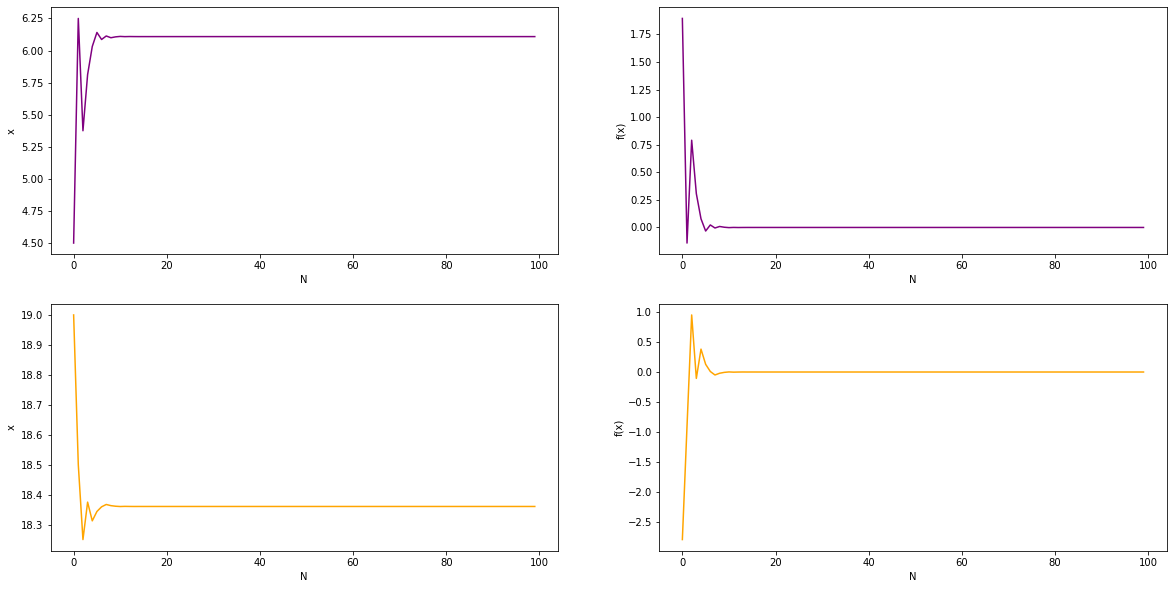

In [180]:
"""Bisection method graphs for part 2"""

fig, ((ax1, ax2), (ax3,ax4)) = plt.subplots(2,2,figsize=(20,10))

ax1.plot(bis_arr3[0],bis_arr3[1],color='purple')
ax1.set_xlabel("N")
ax1.set_ylabel("x")

ax2.plot(bis_arr3[0],bis_arr3[4],color='purple')
ax2.set_xlabel("N")
ax2.set_ylabel("f(x)")

ax3.plot(bis_arr4[0],bis_arr4[1],color='orange')
ax3.set_xlabel("N")
ax3.set_ylabel("x")

ax4.plot(bis_arr4[0],bis_arr4[4],color='orange')
ax4.set_xlabel("N")
ax4.set_ylabel("f(x)")

In [183]:
see = NR3(8)
mee = NR3(18)

j = {'N': see[0],'x_value':see[1],'f(x)': see[2]}
k = {'N': mee[0],'x_value':mee[1],'f(x)': mee[2]}
df = pd.DataFrame(j)

dg = pd.DataFrame(k)

print("\n\nTable for root 6.108467\n\n",df,"\n\nTable for root 18.360520\n\n",dg)

5.860265674199623 0.2562788373017857
6.1002126963071435 0.008351856194422691
6.108460165169301 6.928614121104459e-06
6.108467017542558 5.125677660089423e-12
18.20574180988103 1.4207866660176451
18.329534879126513 0.24177941009513138
18.359232757476015 0.009697222845437281
18.36051753879389 1.7405748066856574e-05
18.36051985245921 5.6619597899043583e-11


Table for root 6.108467

    N   x_value          f(x)
0  0  5.860266  2.562788e-01
1  1  6.100213  8.351856e-03
2  2  6.108460  6.928614e-06
3  3  6.108467  5.125678e-12 

Table for root 18.360520

    N    x_value          f(x)
0  0  18.205742  1.420787e+00
1  1  18.329535  2.417794e-01
2  2  18.359233  9.697223e-03
3  3  18.360518  1.740575e-05
4  4  18.360520  5.661960e-11


Text(0, 0.5, 'f(x)')

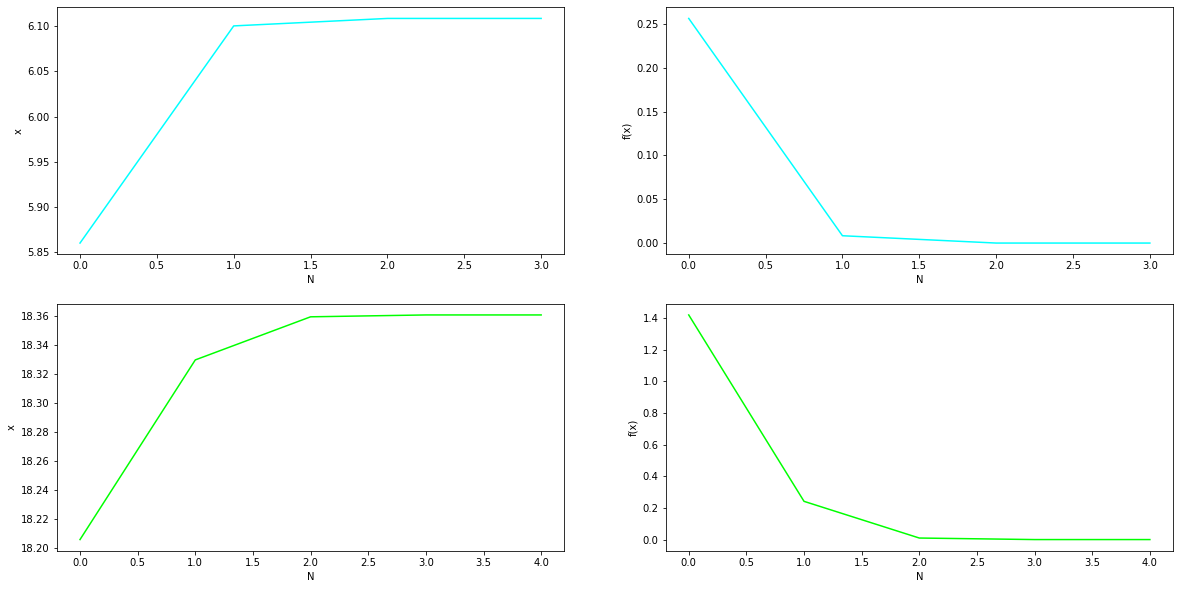

In [185]:
"""Newton-Raphson graphs for part 2"""

fig, ((ax1, ax2), (ax3, ax4)) = plt.subplots(2,2,figsize=(20,10))

ax1.plot(see[0],see[1], color='cyan')
ax1.set_xlabel("N")
ax1.set_ylabel("x")

ax2.plot(see[0],see[2], color='cyan')
ax2.set_xlabel("N")
ax2.set_ylabel("f(x)")

ax3.plot(mee[0],mee[1], color='lime')
ax3.set_xlabel("N")
ax3.set_ylabel("x")

ax4.plot(mee[0],mee[2], color='lime')
ax4.set_xlabel("N")
ax4.set_ylabel("f(x)")

#### 1.x = 6.108467 f(x) = 5.125678e-12   

the number of iterations it took for it to reach that value is 3 iterations

#### 2. x = 18.360520 f(x) = 5.661960e-11

the number of iterations it took for it to reach that value is 4  iterations